# Session behavior + funcimg trial summary

This notebook audits every `ses-*` folder for `behav` and `funcimg` subfolders, then summarizes the sessions that have both modalities. Trial counts include `num_t_found` entries, which are usually dropped from downstream trial extraction.

In [ ]:
from pathlib import Path
import json
import re
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "scripts":
    PROJECT_ROOT = PROJECT_ROOT.parent
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

for path in (PROJECT_ROOT, SCRIPTS_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from src.behavior_import.import_data import import_data
from src.behavior_import.extract_trials import extract_trials_grouped_by_problem
from src.behavior_analysis.get_good_reversal_info import get_good_reversal_info
from src.behavior_analysis.get_rank_counts_by_good_reversal import get_rank_counts_by_good_reversal
from src.behavior_analysis.get_diagnostic_p_value import pvalue_paired_t_best_vs_second_vs_third
import src.behavior_visualization.plot_style  # noqa: F401  # applies shared matplotlib rcParams
from src.behavior_visualization.plot_rank_proportions import plot_rank_proportions
from src.behavior_visualization.plot_style import MOUSE_COLORS
from scripts.fix_grid_maze_cohort_02_problems import fix_grid_maze_cohort_02_problems

# Analysis label and SMB experiment folder. Edit these three values as needed.
task = "open-field"
cohort = "cohort-01"
folder_name = "3x3_field_blocked_reward_bandit"

# For grid maze, use:
# task = "grid-maze"
# cohort = "cohort-02"
# folder_name = "3x3_maze_blocked_reward_bandit"

root = f"/Volumes/behrens/meg/{folder_name}/{cohort}/rawdata/"
DATA_ROOT = Path(root)
MIN_SESSION_DATE = pd.Timestamp("2026-05-22")

SESSION_RE = re.compile(r"ses-(?P<session_number>\d+)_date-(?P<date>\d{8})$")
SUBJECT_RE = re.compile(r"sub-(?P<subject_number>\d+)_id-(?P<subject_id>.+)$")
TRIAL_KEYS = {
    "num_trials",
    "num_t",
    "trial",
    "num_t_found",
}
REGULAR_TRIAL_KEYS = TRIAL_KEYS - {"num_t_found"}
CHOICE_TOWER_KEYS = (
    "current_choice_towers",
    "curr_choice_tows",
    "choice_towers",
    "c_tows",
)
INITIATION_TOWER_KEYS = (
    "current_initiation_tower",
    "curr_initiation_tow",
    "initiation_tower",
)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)

DATA_ROOT

PosixPath('/Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata')

## Resolve and check the rawdata root

In [62]:
def count_files_fast(root_path, pattern, stop_after=1):
    root_path = Path(root_path)
    if not root_path.exists():
        return 0
    count = 0
    for _ in root_path.rglob(pattern):
        count += 1
        if count >= stop_after:
            return count
    return count


def find_candidate_rawdata_roots(folder_name, cohort):
    base = Path("/Volumes/behrens/meg") / folder_name / cohort
    candidates = []
    if base.exists():
        candidates.append(base / "rawdata")
        candidates.extend(sorted(base.glob("problem-*/rawdata")))
    return [p for p in candidates if p.exists()]


print(f"Requested root: {DATA_ROOT}")
print(f"Root exists: {DATA_ROOT.exists()}")
print(f"Contains TSV files: {bool(count_files_fast(DATA_ROOT, '*.tsv'))}")
print(f"Contains session folders: {bool(count_files_fast(DATA_ROOT, 'ses-*_date-*'))}")

candidate_roots = find_candidate_rawdata_roots(folder_name, cohort)
candidate_summary = pd.DataFrame([
    {
        "candidate_root": p,
        "has_tsv": bool(count_files_fast(p, "*.tsv")),
        "has_sessions": bool(count_files_fast(p, "ses-*_date-*")),
    }
    for p in candidate_roots
])

if not candidate_summary.empty:
    display(candidate_summary)

if not DATA_ROOT.exists() or not count_files_fast(DATA_ROOT, "*.tsv"):
    usable = candidate_summary[candidate_summary["has_tsv"]] if not candidate_summary.empty else pd.DataFrame()
    if not usable.empty:
        DATA_ROOT = Path(usable.iloc[0]["candidate_root"])
        root = str(DATA_ROOT)
        print(f"Using detected rawdata root instead: {DATA_ROOT}")
    else:
        print("No TSV-containing rawdata root detected. Check folder_name, cohort, problem_name, and that the SMB volume is mounted.")

DATA_ROOT

Requested root: /Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata
Root exists: True
Contains TSV files: True
Contains session folders: True


,candidate_root,has_tsv,has_sessions
0,/Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata,True,True


PosixPath('/Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata')

## Load behavior data with project helpers

In [63]:
# This follows the standard project workflow and gives you the usual extracted object
# for any downstream analyses. The table below does its own raw TSV count so that
# num_t_found entries are included in num_trials_including_num_t_found.
if DATA_ROOT.exists() and count_files_fast(DATA_ROOT, "*.tsv"):
    subjects_data = import_data(root)
    subjects_trials_by_problem = extract_trials_grouped_by_problem(subjects_data)
    if task == "grid-maze" and cohort == "cohort-02":
        subjects_trials_by_problem = fix_grid_maze_cohort_02_problems(subjects_trials_by_problem)
else:
    subjects_data = {}
    subjects_trials_by_problem = {}
    print("Skipping import_data because DATA_ROOT does not contain TSV files.")

[WARN] Failed to read /Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-01_id-MY_71_N/ses-08_date-20260204/behav/._MY_71_N-2026-02-04-153602.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-05_id-MY_72_L/ses-155_date-20260613/behav/._MY_72_L-2026-06-13-201430.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-02_id-MY_71_L/ses-54_date-20260305/behav/._MY_71_L-2026-03-05-150416.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-04_id-MY_72_N/ses-40_date-20260225/behav/._MY_72_N-2026-02-25-143929.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /

## Helpers

In [64]:
def safe_json_load(value):
    if pd.isna(value):
        return {}
    if isinstance(value, dict):
        return value
    try:
        loaded = json.loads(value)
    except Exception:
        return {}
    return loaded if isinstance(loaded, dict) else {}


def parse_session_dir(session_dir):
    session_match = SESSION_RE.match(session_dir.name)
    if not session_match:
        return None

    subject_key = None
    subject_id = None
    subject_number = None
    for part in session_dir.parts:
        subject_match = SUBJECT_RE.match(part)
        if subject_match:
            subject_key = part
            subject_id = subject_match.group("subject_id")
            subject_number = int(subject_match.group("subject_number"))
            break

    date = pd.to_datetime(session_match.group("date"), format="%Y%m%d")
    return {
        "subject_key": subject_key,
        "subject_id": subject_id,
        "subject_number": subject_number,
        "ses_id": session_dir.name,
        "session_number": int(session_match.group("session_number")),
        "date": date,
        "session_dir": session_dir,
        "behav_dir": session_dir / "behav",
        "funcimg_dir": session_dir / "funcimg",
    }


def find_session_dirs(root):
    return sorted(
        (p for p in root.rglob("ses-*_date-*") if p.is_dir() and SESSION_RE.match(p.name)),
        key=lambda p: str(p),
    )


def read_behav_tsvs(behav_dir):
    dfs = []
    for tsv_path in sorted(behav_dir.glob("*.tsv")):
        try:
            dfs.append(pd.read_csv(tsv_path, sep="\t"))
        except Exception as exc:
            print(f"[WARN] Failed to read {tsv_path}: {exc}")
    return dfs


def get_run_start(dfs):
    for df in dfs:
        needed_cols = {"type", "subtype", "content"}
        if not needed_cols.issubset(df.columns):
            continue
        rows = df.loc[df["type"].eq("variable") & df["subtype"].eq("run_start"), "content"]
        for content in rows:
            parsed = safe_json_load(content)
            if parsed:
                return parsed
    return {}


def problem_signature_from_run_start(run_start):
    if not run_start:
        return "unknown"

    choice_towers = None
    for key in CHOICE_TOWER_KEYS:
        if key in run_start and run_start[key] is not None:
            choice_towers = list(run_start[key])
            break

    initiation_tower = None
    for key in INITIATION_TOWER_KEYS:
        if key in run_start and run_start[key] is not None:
            initiation_tower = run_start[key]
            break

    if choice_towers is None and "problems" in run_start and "num_problem" in run_start:
        problem_key = str(run_start["num_problem"])
        tower_list = run_start.get("problems", {}).get(problem_key)
        if isinstance(tower_list, list):
            if len(tower_list) == 4:
                initiation_tower = tower_list[0]
                choice_towers = tower_list[1:]
            else:
                initiation_tower = initiation_tower or "B2"
                choice_towers = tower_list

    if choice_towers is None:
        return "unknown"

    choice_sig = "+".join(sorted(map(str, choice_towers)))
    if initiation_tower:
        return f"init={initiation_tower}; choices={choice_sig}"
    return f"choices={choice_sig}"


def count_trials_including_num_t_found(dfs):
    total = 0
    for df in dfs:
        needed_cols = {"type", "subtype", "content"}
        if not needed_cols.issubset(df.columns):
            continue
        trial_rows = df[df["type"].eq("variable") & df["subtype"].eq("print")]
        for content in trial_rows["content"]:
            parsed = safe_json_load(content)
            if TRIAL_KEYS.intersection(parsed):
                total += 1
    return total


def count_trials_excluding_num_t_found(dfs):
    total = 0
    for df in dfs:
        needed_cols = {"type", "subtype", "content"}
        if not needed_cols.issubset(df.columns):
            continue
        trial_rows = df[df["type"].eq("variable") & df["subtype"].eq("print")]
        for content in trial_rows["content"]:
            parsed = safe_json_load(content)
            if REGULAR_TRIAL_KEYS.intersection(parsed):
                total += 1
    return total


def build_modality_table(root):
    rows = []
    for session_dir in find_session_dirs(root):
        parsed = parse_session_dir(session_dir)
        if parsed is None:
            continue
        rows.append({
            **parsed,
            "has_behav": parsed["behav_dir"].is_dir(),
            "has_funcimg": parsed["funcimg_dir"].is_dir(),
        })
    table = pd.DataFrame(rows)
    if table.empty:
        return table
    return table.sort_values(["subject_key", "date", "session_number"]).reset_index(drop=True)


def summarize_complete_sessions(modality_table):
    rows = []
    complete = modality_table[modality_table["has_behav"] & modality_table["has_funcimg"]]
    for _, row in complete.iterrows():
        dfs = read_behav_tsvs(row["behav_dir"])
        rows.append({
            "subject_key": row["subject_key"],
            "subject_id": row["subject_id"],
            "ses_id": row["ses_id"],
            "session_number": row["session_number"],
            "date": pd.Timestamp(row["date"]).normalize(),
            "num_trials_including_num_t_found": count_trials_including_num_t_found(dfs),
            "num_trials_excluding_num_t_found": count_trials_excluding_num_t_found(dfs),
            "problem_signature": problem_signature_from_run_start(get_run_start(dfs)),
            "session_dir": row["session_dir"],
        })
    summary = pd.DataFrame(rows)
    if summary.empty:
        return summary
    return summary.sort_values(["subject_key", "date", "session_number"]).reset_index(drop=True)

## Audit every session folder for `behav` and `funcimg`

In [65]:
modality_table = build_modality_table(DATA_ROOT)

print(f"Data root: {DATA_ROOT}")
print(f"Session folders found: {len(modality_table)}")
if not modality_table.empty:
    print(f"Sessions with behav: {int(modality_table['has_behav'].sum())}")
    print(f"Sessions with funcimg: {int(modality_table['has_funcimg'].sum())}")
    print(f"Sessions with both: {int((modality_table['has_behav'] & modality_table['has_funcimg']).sum())}")

display_cols = [
    "subject_key",
    "ses_id",
    "date",
    "has_behav",
    "has_funcimg",
    "session_dir",
]
display(modality_table[display_cols] if not modality_table.empty else modality_table)

Data root: /Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata
Session folders found: 788
Sessions with behav: 788
Sessions with funcimg: 61
Sessions with both: 61


,subject_key,ses_id,date,has_behav,has_funcimg,session_dir
0,sub-01_id-MY_71_N,ses-01_date-20260201,2026-02-01,True,False,/Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-01_id-MY_71_N/ses-01_date-20260201
1,sub-01_id-MY_71_N,ses-02_date-20260201,2026-02-01,True,False,/Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-01_id-MY_71_N/ses-02_date-20260201
2,sub-01_id-MY_71_N,ses-03_date-20260202,2026-02-02,True,False,/Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-01_id-MY_71_N/ses-03_date-20260202
3,sub-01_id-MY_71_N,ses-04_date-20260202,2026-02-02,True,False,/Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-01_id-MY_71_N/ses-04_date-20260202
4,sub-01_id-MY_71_N,ses-05_date-20260203,2026-02-03,True,False,/Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-01_id-MY_71_N/ses-05_date-20260203
...,...,...,...,...,...,...
783,sub-06_id-MY_72_R,ses-95_date-20260401,2026-04-01,True,False,/Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-06_id-MY_72_R/ses-95_date-20260401
784,sub-06_id-MY_72_R,ses-96_date-20260401,2026-04-01,True,False,/Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-06_id-MY_72_R/ses-96_date-20260401
785,sub-06_id-MY_72_R,ses-97_date-20260402,2026-04-02,True,False,/Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-06_id-MY_72_R/ses-97_date-20260402
786,sub-06_id-MY_72_R,ses-98_date-20260402,2026-04-02,True,False,/Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-06_id-MY_72_R/ses-98_date-20260402


## Complete-session summary tables, one per subject

Only sessions on or after `MIN_SESSION_DATE` are included here and in the plots below. Session, day, and signature labels are relative to each mouse's imaging data.

In [66]:
def add_imaging_relative_fields(summary):
    summary = summary.sort_values(["subject_key", "date", "session_number"]).copy()
    pieces = []

    for subject_key, subject_table in summary.groupby("subject_key", sort=True):
        subject_table = subject_table.sort_values(["date", "session_number"]).copy()
        subject_table["imaging_session"] = range(1, len(subject_table) + 1)

        day_lookup = {
            date: i + 1
            for i, date in enumerate(sorted(subject_table["date"].dropna().unique()))
        }
        subject_table["imaging_day"] = subject_table["date"].map(day_lookup)

        signature_lookup = {}
        signature_labels = []
        for signature in subject_table["problem_signature"]:
            if signature not in signature_lookup:
                signature_lookup[signature] = len(signature_lookup) + 1
            signature_number = signature_lookup[signature]
            signature_labels.append(f"imaging signature {signature_number}")
        subject_table["imaging_signature_number"] = [signature_lookup[s] for s in subject_table["problem_signature"]]
        subject_table["imaging_signature"] = signature_labels

        pieces.append(subject_table)

    return pd.concat(pieces, ignore_index=True) if pieces else summary


def build_break_table(modality_table, imaging_summary):
    if modality_table.empty or imaging_summary.empty:
        return pd.DataFrame()

    modality = modality_table.copy()
    modality["date"] = pd.to_datetime(modality["date"]).dt.normalize()
    rows = []

    for subject_key, imaging_table in imaging_summary.groupby("subject_key", sort=True):
        imaging_table = imaging_table.sort_values(["date", "session_number"]).reset_index(drop=True)
        subject_modalities = modality[modality["subject_key"].eq(subject_key)].copy()
        subject_modalities = subject_modalities[pd.to_datetime(subject_modalities["date"]) >= MIN_SESSION_DATE]
        subject_modalities = subject_modalities.sort_values(["date", "session_number"])

        for i in range(len(imaging_table) - 1):
            prev = imaging_table.iloc[i]
            nxt = imaging_table.iloc[i + 1]

            after_prev = (
                (subject_modalities["date"] > prev["date"])
                | ((subject_modalities["date"] == prev["date"]) & (subject_modalities["session_number"] > prev["session_number"]))
            )
            before_next = (
                (subject_modalities["date"] < nxt["date"])
                | ((subject_modalities["date"] == nxt["date"]) & (subject_modalities["session_number"] < nxt["session_number"]))
            )
            between = subject_modalities[after_prev & before_next]
            behav_only = between[between["has_behav"] & ~between["has_funcimg"]]

            n_behav_only_sessions = len(behav_only)
            n_behav_only_days = behav_only["date"].nunique()
            date_gap_days = int((nxt["date"] - prev["date"]).days)
            no_session_days = date_gap_days - 1 if nxt["session_number"] == prev["session_number"] + 1 and date_gap_days > 1 else 0

            notes = []
            if n_behav_only_sessions:
                notes.append(f"{n_behav_only_sessions} behav-only sessions, {n_behav_only_days} days")
            if no_session_days:
                notes.append(f"no sessions for {no_session_days} days")

            if notes:
                rows.append({
                    "subject_key": subject_key,
                    "from_ses_id": prev["ses_id"],
                    "to_ses_id": nxt["ses_id"],
                    "from_date": prev["date"],
                    "to_date": nxt["date"],
                    "from_imaging_session": prev["imaging_session"],
                    "to_imaging_session": nxt["imaging_session"],
                    "from_imaging_day": prev["imaging_day"],
                    "to_imaging_day": nxt["imaging_day"],
                    "n_behav_only_sessions": n_behav_only_sessions,
                    "n_behav_only_days": n_behav_only_days,
                    "no_session_days": no_session_days,
                    "break_note": "; ".join(notes),
                })

    return pd.DataFrame(rows)


def style_summary_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.grid(axis="y", alpha=0.25, linewidth=1)


def subject_color_map(summary):
    subjects = sorted(summary["subject_key"].dropna().unique())
    return {
        subject_key: MOUSE_COLORS[i % len(MOUSE_COLORS)]
        for i, subject_key in enumerate(subjects)
    }


def add_break_markers(break_table):
    if break_table.empty:
        return break_table
    break_table = break_table.copy().reset_index(drop=True)
    break_table["break_marker"] = [f"B{i + 1}" for i in range(len(break_table))]
    return break_table


def add_break_lines(ax, break_table, x_col):
    if break_table.empty:
        return
    for _, row in break_table.dropna(subset=[x_col]).iterrows():
        x = row[x_col]
        ax.axvline(x, color="0.65", linestyle="--", linewidth=1.5, alpha=0.7, zorder=0)
        ax.annotate(
            row.get("break_marker", ""),
            xy=(x, 1.0),
            xycoords=("data", "axes fraction"),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            color="0.35",
        )


def display_break_table(break_table):
    if break_table.empty:
        print("No breaks detected between included imaging sessions.")
        return

    display(
        break_table[[
            "break_marker",
            "subject_key",
            "from_ses_id",
            "to_ses_id",
            "n_behav_only_sessions",
            "n_behav_only_days",
            "no_session_days",
            "break_note",
        ]]
    )


all_session_summary = summarize_complete_sessions(modality_table)

if all_session_summary.empty:
    session_summary = all_session_summary
    break_table = pd.DataFrame()
    print("No sessions currently have both behav and funcimg folders under DATA_ROOT.")
else:
    session_summary = all_session_summary[
        pd.to_datetime(all_session_summary["date"]) >= MIN_SESSION_DATE
    ].copy()
    session_summary = add_imaging_relative_fields(session_summary)
    break_table = add_break_markers(build_break_table(modality_table, session_summary))

    print(f"Complete sessions before date filter: {len(all_session_summary)}")
    print(f"Complete sessions on or after {MIN_SESSION_DATE.date()}: {len(session_summary)}")

    for subject_key, subject_table in session_summary.groupby("subject_key", sort=True):
        print(f"\n{subject_key}")
        display(subject_table[[
            "ses_id",
            "date",
            "imaging_session",
            "imaging_day",
            "num_trials_including_num_t_found",
            "num_trials_excluding_num_t_found",
            "imaging_signature",
            "problem_signature",
        ]])

    print("\nBreaks detected between included imaging sessions:")
    display_break_table(break_table)

[WARN] Failed to read /Volumes/behrens/meg/3x3_field_blocked_reward_bandit/cohort-01/rawdata/sub-05_id-MY_72_L/ses-155_date-20260613/behav/._MY_72_L-2026-06-13-201430.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte
Complete sessions before date filter: 61
Complete sessions on or after 2026-05-22: 57

sub-03_id-MY_71_R


,ses_id,date,imaging_session,imaging_day,num_trials_including_num_t_found,num_trials_excluding_num_t_found,imaging_signature,problem_signature
0,ses-130_date-20260522,2026-05-22,1,1,16,0,imaging signature 1,init=B2; choices=A2+B1+C2
1,ses-131_date-20260522,2026-05-22,2,1,40,38,imaging signature 1,init=B2; choices=A2+B1+C2
2,ses-135_date-20260525,2026-05-25,3,2,13,13,imaging signature 1,init=B2; choices=A2+B1+C2
3,ses-136_date-20260526,2026-05-26,4,3,23,23,imaging signature 1,init=B2; choices=A2+B1+C2
4,ses-137_date-20260526,2026-05-26,5,3,26,26,imaging signature 1,init=B2; choices=A2+B1+C2
5,ses-138_date-20260526,2026-05-26,6,3,56,56,imaging signature 1,init=B2; choices=A2+B1+C2
6,ses-155_date-20260608,2026-06-08,7,4,19,2,imaging signature 2,init=B2; choices=A3+B3+C2
7,ses-156_date-20260609,2026-06-09,8,5,5,5,imaging signature 2,init=B2; choices=A3+B3+C2
8,ses-157_date-20260609,2026-06-09,9,5,5,5,imaging signature 2,init=B2; choices=A3+B3+C2
9,ses-158_date-20260612,2026-06-12,10,6,54,54,imaging signature 2,init=B2; choices=A3+B3+C2



sub-05_id-MY_72_L


,ses_id,date,imaging_session,imaging_day,num_trials_including_num_t_found,num_trials_excluding_num_t_found,imaging_signature,problem_signature
27,ses-150_date-20260610,2026-06-10,1,1,0,0,imaging signature 1,init=B2; choices=A1+A2+C2
28,ses-151_date-20260611,2026-06-11,2,2,3,0,imaging signature 1,init=B2; choices=A1+A2+C2
29,ses-152_date-20260611,2026-06-11,3,2,2,0,imaging signature 1,init=B2; choices=A1+A2+C2
30,ses-153_date-20260612,2026-06-12,4,3,15,0,imaging signature 1,init=B2; choices=A1+A2+C2
31,ses-154_date-20260612,2026-06-12,5,3,6,2,imaging signature 1,init=B2; choices=A1+A2+C2
32,ses-155_date-20260613,2026-06-13,6,4,23,23,imaging signature 1,init=B2; choices=A1+A2+C2
33,ses-159_date-20260617,2026-06-17,7,5,0,0,imaging signature 1,init=B2; choices=A1+A2+C2
34,ses-160_date-20260618,2026-06-18,8,6,2,2,imaging signature 1,init=B2; choices=A1+A2+C2
35,ses-161_date-20260618,2026-06-18,9,6,26,26,imaging signature 1,init=B2; choices=A1+A2+C2
36,ses-162_date-20260619,2026-06-19,10,7,8,8,imaging signature 1,init=B2; choices=A1+A2+C2



Breaks detected between included imaging sessions:


,break_marker,subject_key,from_ses_id,to_ses_id,n_behav_only_sessions,n_behav_only_days,no_session_days,break_note
0,B1,sub-03_id-MY_71_R,ses-131_date-20260522,ses-135_date-20260525,3,2,0,"3 behav-only sessions, 2 days"
1,B2,sub-03_id-MY_71_R,ses-138_date-20260526,ses-155_date-20260608,16,8,0,"16 behav-only sessions, 8 days"
2,B3,sub-03_id-MY_71_R,ses-157_date-20260609,ses-158_date-20260612,0,0,2,no sessions for 2 days
3,B4,sub-03_id-MY_71_R,ses-160_date-20260612,ses-162_date-20260614,1,1,0,"1 behav-only sessions, 1 days"
4,B5,sub-03_id-MY_71_R,ses-162_date-20260614,ses-165_date-20260617,2,1,0,"2 behav-only sessions, 1 days"
5,B6,sub-03_id-MY_71_R,ses-169_date-20260619,ses-170_date-20260622,0,0,2,no sessions for 2 days
6,B7,sub-05_id-MY_72_L,ses-155_date-20260613,ses-159_date-20260617,3,2,0,"3 behav-only sessions, 2 days"
7,B8,sub-05_id-MY_72_L,ses-164_date-20260619,ses-165_date-20260621,0,0,1,no sessions for 1 days


## Trials By Imaging Session

Both mice are shown on the same axes. Session numbers are relative to each mouse's included imaging sessions.

Breaks shown as dashed vertical lines:


,break_marker,subject_key,from_ses_id,to_ses_id,n_behav_only_sessions,n_behav_only_days,no_session_days,break_note
0,B1,sub-03_id-MY_71_R,ses-131_date-20260522,ses-135_date-20260525,3,2,0,"3 behav-only sessions, 2 days"
1,B2,sub-03_id-MY_71_R,ses-138_date-20260526,ses-155_date-20260608,16,8,0,"16 behav-only sessions, 8 days"
2,B3,sub-03_id-MY_71_R,ses-157_date-20260609,ses-158_date-20260612,0,0,2,no sessions for 2 days
3,B4,sub-03_id-MY_71_R,ses-160_date-20260612,ses-162_date-20260614,1,1,0,"1 behav-only sessions, 1 days"
4,B5,sub-03_id-MY_71_R,ses-162_date-20260614,ses-165_date-20260617,2,1,0,"2 behav-only sessions, 1 days"
5,B6,sub-03_id-MY_71_R,ses-169_date-20260619,ses-170_date-20260622,0,0,2,no sessions for 2 days
6,B7,sub-05_id-MY_72_L,ses-155_date-20260613,ses-159_date-20260617,3,2,0,"3 behav-only sessions, 2 days"
7,B8,sub-05_id-MY_72_L,ses-164_date-20260619,ses-165_date-20260621,0,0,1,no sessions for 1 days


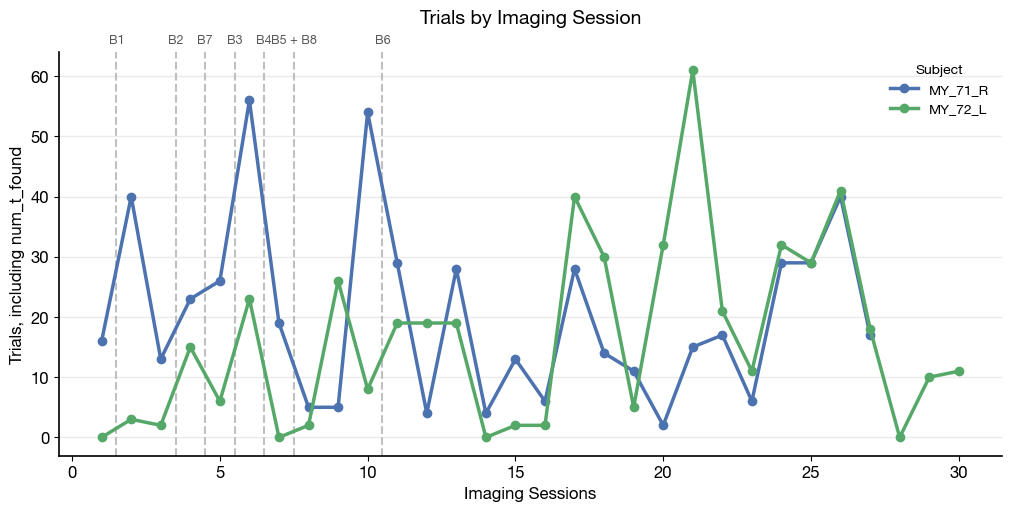

In [67]:
if session_summary.empty:
    print("No complete sessions to plot after the date filter.")
else:
    if not break_table.empty:
        print("Breaks shown as dashed vertical lines:")
        display_break_table(break_table)

    colors = subject_color_map(session_summary)
    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

    for subject_key, subject_table in session_summary.groupby("subject_key", sort=True):
        subject_table = subject_table.sort_values("imaging_session")
        ax.plot(
            subject_table["imaging_session"],
            subject_table["num_trials_including_num_t_found"],
            marker="o",
            markersize=6,
            linewidth=2.5,
            color=colors[subject_key],
            label=subject_key.split("_id-")[1],
        )

    if not break_table.empty:
        day_breaks = break_table.copy()
        day_breaks["x_position"] = (
            day_breaks["from_imaging_day"] + day_breaks["to_imaging_day"]
        ) / 2

        day_breaks = (
            day_breaks
            .groupby("x_position", as_index=False)
            .agg({
                "break_marker": lambda x: " + ".join(sorted(x.astype(str).unique()))
            })
        )

        add_break_lines(ax, day_breaks, "x_position")
    ax.set_title(f"Trials by Imaging Session", y=1.05)
    ax.set_xlabel("Imaging Sessions")
    ax.set_ylabel("Trials, including num_t_found")
    style_summary_axis(ax)
    ax.legend(title="Subject", frameon=False)
    plt.show()

## Trials By Imaging Day

Trials are summed across sessions within each mouse-relative imaging day.

Breaks shown as dashed vertical lines:


,break_marker,subject_key,from_ses_id,to_ses_id,n_behav_only_sessions,n_behav_only_days,no_session_days,break_note
0,B1,sub-03_id-MY_71_R,ses-131_date-20260522,ses-135_date-20260525,3,2,0,"3 behav-only sessions, 2 days"
1,B2,sub-03_id-MY_71_R,ses-138_date-20260526,ses-155_date-20260608,16,8,0,"16 behav-only sessions, 8 days"
2,B3,sub-03_id-MY_71_R,ses-157_date-20260609,ses-158_date-20260612,0,0,2,no sessions for 2 days
3,B4,sub-03_id-MY_71_R,ses-160_date-20260612,ses-162_date-20260614,1,1,0,"1 behav-only sessions, 1 days"
4,B5,sub-03_id-MY_71_R,ses-162_date-20260614,ses-165_date-20260617,2,1,0,"2 behav-only sessions, 1 days"
5,B6,sub-03_id-MY_71_R,ses-169_date-20260619,ses-170_date-20260622,0,0,2,no sessions for 2 days
6,B7,sub-05_id-MY_72_L,ses-155_date-20260613,ses-159_date-20260617,3,2,0,"3 behav-only sessions, 2 days"
7,B8,sub-05_id-MY_72_L,ses-164_date-20260619,ses-165_date-20260621,0,0,1,no sessions for 1 days


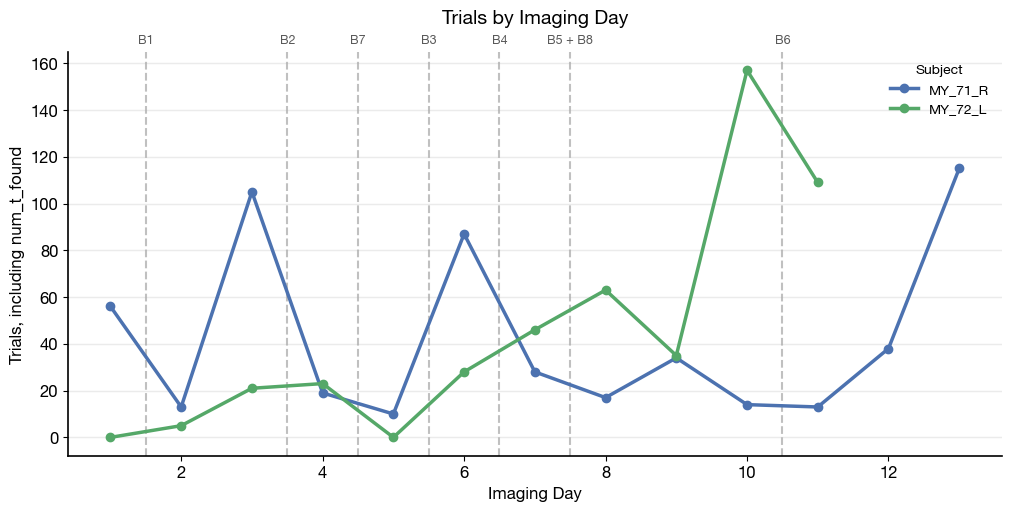

In [68]:
if session_summary.empty:
    print("No complete sessions to plot after the date filter.")
else:
    if not break_table.empty:
        print("Breaks shown as dashed vertical lines:")
        display_break_table(break_table)

    colors = subject_color_map(session_summary)
    daily_trials = (
        session_summary
        .groupby(["subject_key", "imaging_day"], as_index=False)["num_trials_including_num_t_found"]
        .sum()
        .sort_values(["subject_key", "imaging_day"])
    )

    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    for subject_key, subject_table in daily_trials.groupby("subject_key", sort=True):
        ax.plot(
            subject_table["imaging_day"],
            subject_table["num_trials_including_num_t_found"],
            marker="o",
            markersize=6,
            linewidth=2.5,
            color=colors[subject_key],
            label=subject_key.split("_id-")[1],
        )

    if not break_table.empty:
        day_breaks = break_table.copy()
        day_breaks["x_position"] = (
            day_breaks["from_imaging_day"] + day_breaks["to_imaging_day"]
        ) / 2

        day_breaks = (
            day_breaks
            .groupby("x_position", as_index=False)
            .agg({
                "break_marker": lambda x: " + ".join(sorted(x.astype(str).unique()))
            })
        )

        add_break_lines(ax, day_breaks, "x_position")

    ax.set_title(f"Trials by Imaging Day", y=1.05)
    ax.set_xlabel("Imaging Day")
    ax.set_ylabel("Trials, including num_t_found")
    style_summary_axis(ax)
    ax.legend(title="Subject", frameon=False)
    plt.show()

## Imaging Signature Mapping

Problem signatures are labeled relative to each mouse. The first unique imaging problem for each mouse is `imaging signature 1`, the next unique imaging problem is `imaging signature 2`, and so on.

In [69]:
if session_summary.empty:
    signature_summary = pd.DataFrame()
    signature_order = []
    print("No complete sessions to summarize after the date filter.")
else:
    signature_summary = session_summary.copy()
    signature_order = [
        f"imaging signature {i}"
        for i in range(1, int(signature_summary["imaging_signature_number"].max()) + 1)
    ]
    signature_summary["imaging_signature"] = pd.Categorical(
        signature_summary["imaging_signature"],
        categories=signature_order,
        ordered=True,
    )
    signature_lookup = (
        signature_summary[["subject_key", "imaging_signature_number", "imaging_signature", "problem_signature"]]
        .drop_duplicates()
        .sort_values(["subject_key", "imaging_signature_number"])
        .reset_index(drop=True)
    )
    display(signature_lookup)

,subject_key,imaging_signature_number,imaging_signature,problem_signature
0,sub-03_id-MY_71_R,1,imaging signature 1,init=B2; choices=A2+B1+C2
1,sub-03_id-MY_71_R,2,imaging signature 2,init=B2; choices=A3+B3+C2
2,sub-03_id-MY_71_R,3,imaging signature 3,init=B2; choices=A1+B1+C1
3,sub-05_id-MY_72_L,1,imaging signature 1,init=B2; choices=A1+A2+C2
4,sub-05_id-MY_72_L,2,imaging signature 2,init=B2; choices=B1+C1+C3
5,sub-05_id-MY_72_L,3,imaging signature 3,init=B2; choices=A3+B3+C3


## Trials By Imaging Signature

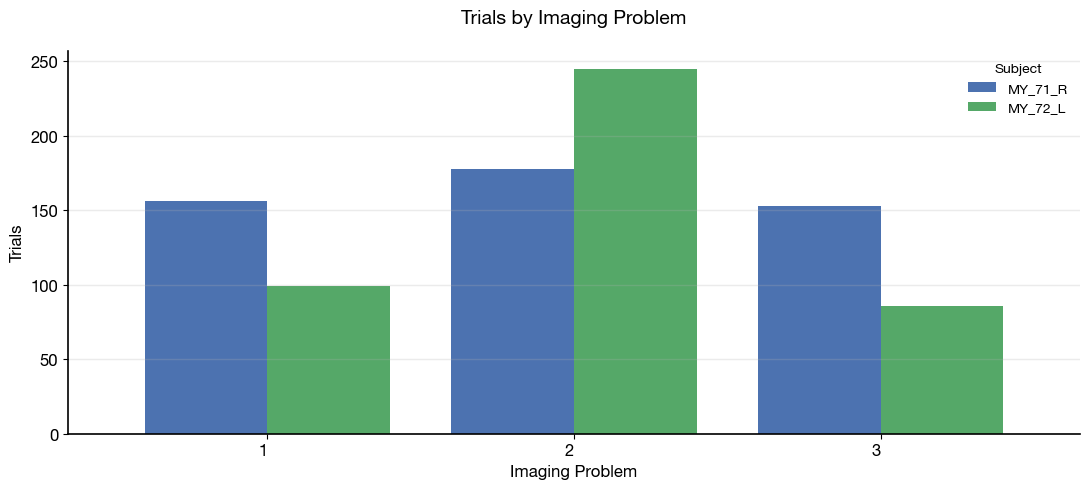

In [76]:
if session_summary.empty:
    print("No complete sessions to plot after the date filter.")
else:
    trials_by_signature = (
        signature_summary
        .groupby(
            ["imaging_signature", "subject_key"],
            as_index=False,
            observed=True
        )["num_trials_excluding_num_t_found"]
        .sum()
    )

    plot_df = trials_by_signature.pivot(
        index="imaging_signature",
        columns="subject_key",
        values="num_trials_excluding_num_t_found",
    ).reindex(signature_order).fillna(0)

    # Clean subject labels
    plot_df.columns = [
        col.split("_id-")[-1]
        for col in plot_df.columns
    ]

    # Clean color map keys
    colors_raw = subject_color_map(session_summary)
    colors = {
        k.split("_id-")[-1]: v
        for k, v in colors_raw.items()
    }

    bar_colors = [colors[col] for col in plot_df.columns]

    ax = plot_df.plot(
        kind="bar",
        figsize=(11, 5),
        width=0.8,
        color=bar_colors,
    )

    ax.set_title("Trials by Imaging Problem", y=1.05)
    ax.set_xlabel("Imaging Problem")
    ax.set_ylabel("Trials")

    style_summary_axis(ax)

    ax.set_xticks(range(len(plot_df.index)))
    ax.set_xticklabels(
        [f"{i+1}" for i in range(len(plot_df.index))],
        rotation=0,
        ha="right",
    )

    ax.legend(title="Subject", frameon=False)

    plt.tight_layout()
    plt.show()

## Days By Imaging Signature

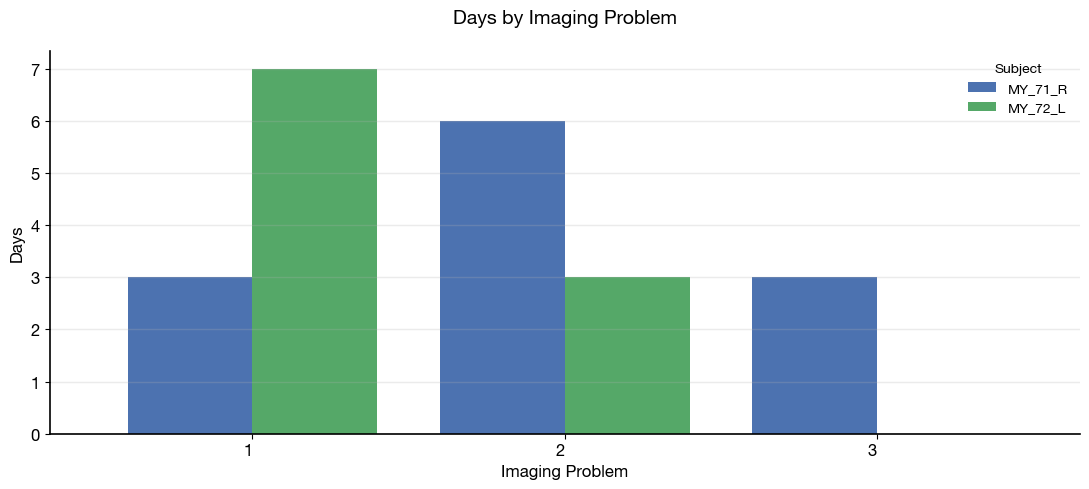

In [75]:
plot_df = days_by_signature.pivot(
    index="imaging_signature",
    columns="subject_key",
    values="num_days",
).reindex(signature_order).fillna(0)

# clean subject labels
old_cols = plot_df.columns.tolist()
new_cols = [col.split("_id-")[-1] for col in old_cols]
plot_df.columns = new_cols

# clean color map keys the same way
colors_raw = subject_color_map(session_summary)
colors = {
    k.split("_id-")[-1]: v
    for k, v in colors_raw.items()
}

bar_colors = [colors[col] for col in plot_df.columns]

ax = plot_df.plot(
    kind="bar",
    figsize=(11, 5),
    width=0.8,
    color=bar_colors,
)

ax.set_title("Days by Imaging Problem", y=1.05)
ax.set_xlabel("Imaging Problem")
ax.set_ylabel("Days")

style_summary_axis(ax)

ax.set_xticks(range(len(plot_df.index)))
ax.set_xticklabels(
    [f"{i+1}" for i in range(len(plot_df.index))],
    rotation=0,
    ha="right",
)

ax.legend(title="Subject", frameon=False)

plt.tight_layout()
plt.show()

## Rank Proportions By Imaging Signature

This runs the existing `plot_rank_proportions` analysis separately for each mouse-relative imaging signature. The input is filtered to sessions that have both `behav` and `funcimg`, so behavior-only sessions are excluded.


imaging signature 1: 2 subjects, 12 imaging sessions
Rank-proportion windows: 7


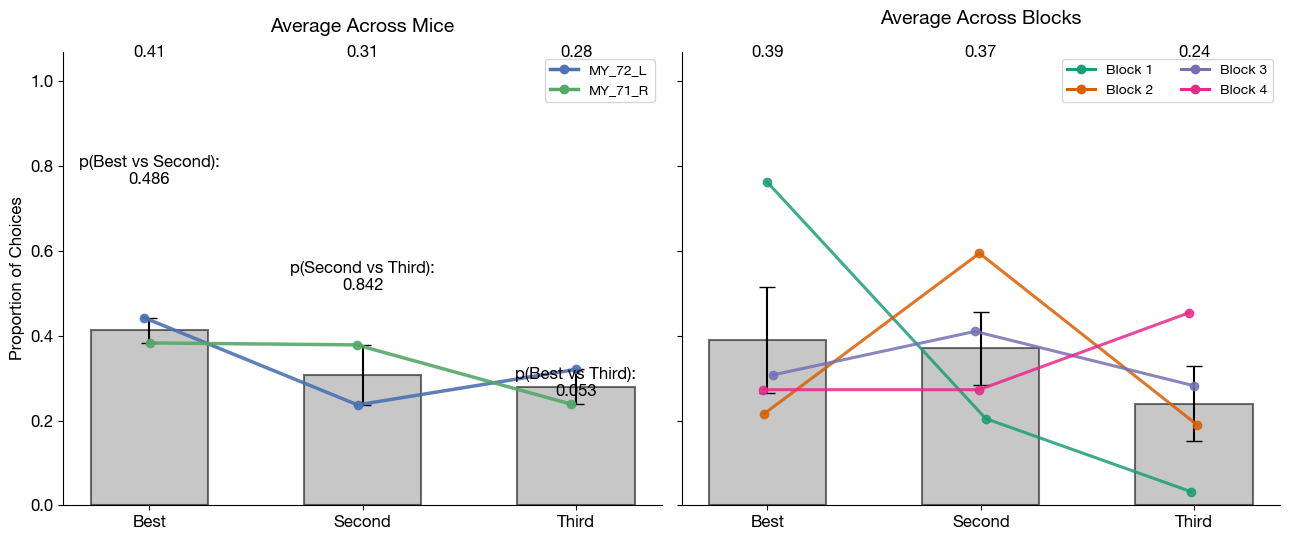


imaging signature 2: 2 subjects, 21 imaging sessions
Rank-proportion windows: 12


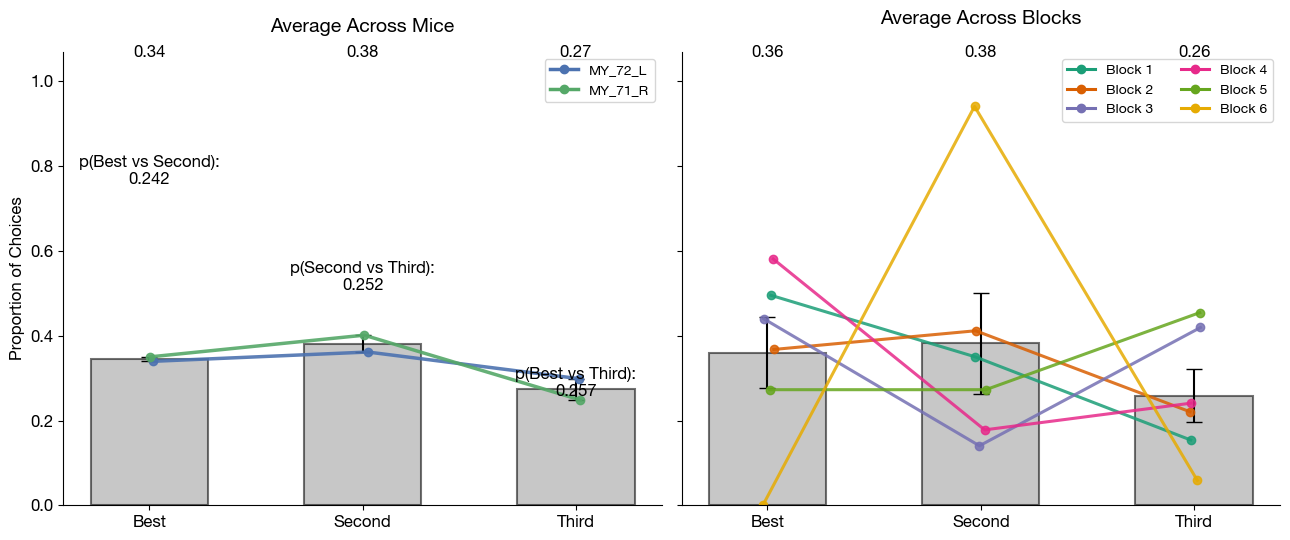


imaging signature 3: 2 subjects, 12 imaging sessions
Rank-proportion windows: 7


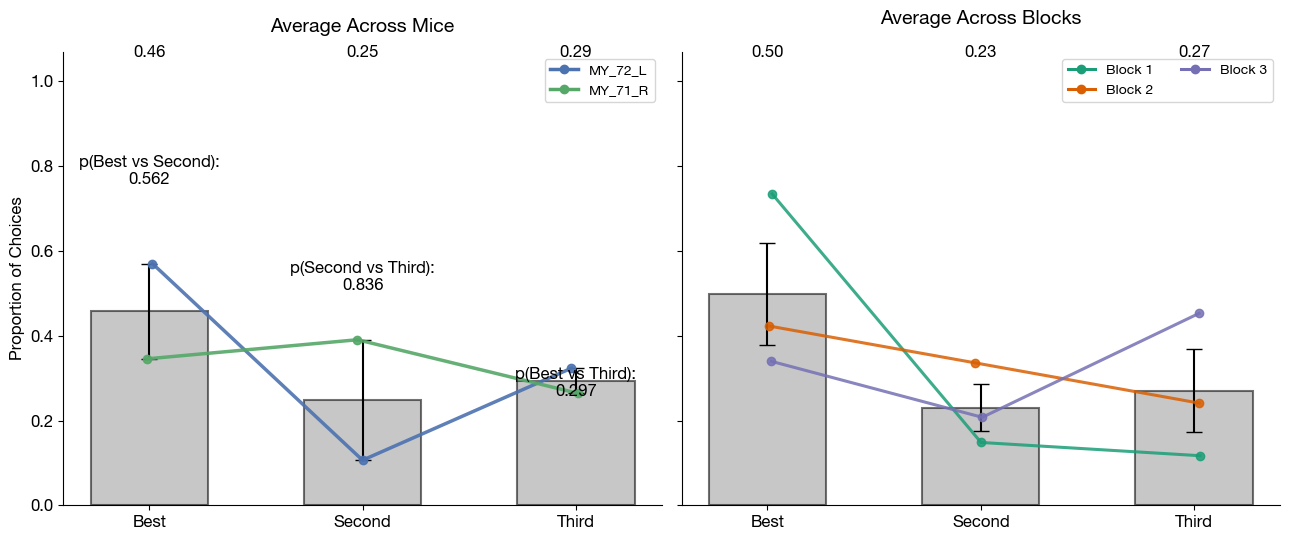

In [72]:
RANK_PRE = 5
RANK_POST = None
RANK_INCLUDE_FIRST_BLOCK = True
RANK_PLOT_BY_MOUSE = False
RANK_PLOT_BY_BLOCK = False
RANK_PLOT_AVERAGE = True


def build_imaging_signature_trial_groups(subjects_trials_by_problem, session_summary):
    if not subjects_trials_by_problem or session_summary.empty:
        return {}

    imaging_lookup = {
        (row["subject_id"], row["ses_id"]): row["imaging_signature"]
        for _, row in session_summary.iterrows()
    }

    groups = {signature: {} for signature in session_summary["imaging_signature"].cat.categories}
    for _, problem_subjects in subjects_trials_by_problem.items():
        for subject_id, subject_sessions in problem_subjects.items():
            for ses_id, session_data in subject_sessions.items():
                signature = imaging_lookup.get((subject_id, ses_id))
                if signature is None:
                    continue
                groups.setdefault(signature, {}).setdefault(subject_id, {})[ses_id] = session_data

    return {signature: subjects for signature, subjects in groups.items() if subjects}


imaging_signature_trial_groups = build_imaging_signature_trial_groups(subjects_trials_by_problem, signature_summary)

if not imaging_signature_trial_groups:
    print("No imaging-signature trial groups found. Run the cells above and confirm complete imaging sessions exist.")
else:
    rank_results_by_imaging_signature = {}

    for imaging_signature in signature_order:
        subjects_trials = imaging_signature_trial_groups.get(imaging_signature)
        if not subjects_trials:
            continue

        n_sessions = sum(len(sessions) for sessions in subjects_trials.values())
        print(f"\n{imaging_signature}: {len(subjects_trials)} subjects, {n_sessions} imaging sessions")

        reversal_windows = get_good_reversal_info(
            subjects_trials,
            pre=RANK_PRE,
            post=RANK_POST,
            include_first_block=RANK_INCLUDE_FIRST_BLOCK,
        )
        rank_counts_by_good_reversal = get_rank_counts_by_good_reversal(reversal_windows)
        n_reversals = sum(len(rows) for rows in rank_counts_by_good_reversal.values())
        print(f"Rank-proportion windows: {n_reversals}")

        if n_reversals == 0:
            print(f"Skipping {imaging_signature}: no usable reversal windows.")
            continue

        p_values = pvalue_paired_t_best_vs_second_vs_third(rank_counts_by_good_reversal)
        rank_results_by_imaging_signature[imaging_signature] = {
            "subjects_trials": subjects_trials,
            "reversal_windows": reversal_windows,
            "rank_counts_by_good_reversal": rank_counts_by_good_reversal,
            "p_values": p_values,
        }

        plot_rank_proportions(
            rank_counts_by_good_reversal,
            average_across_mice_pvalues=p_values,
            save_path=None,
            by_mouse=RANK_PLOT_BY_MOUSE,
            by_block=RANK_PLOT_BY_BLOCK,
            average=RANK_PLOT_AVERAGE,
        )

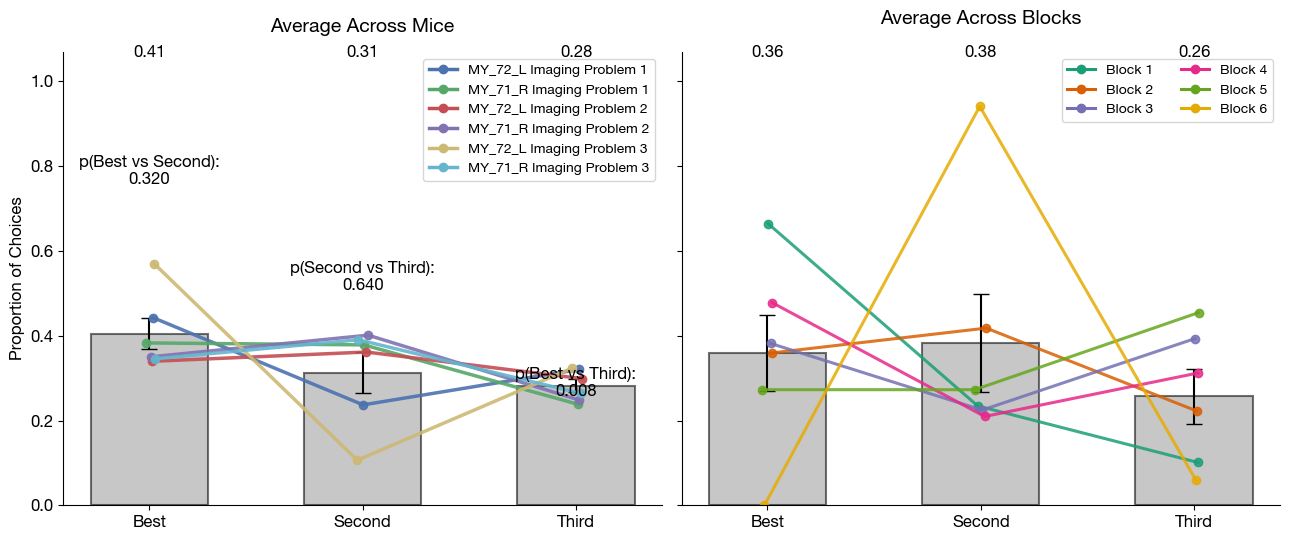

In [73]:
# ----------------------------
# Combined plot across all imaging problems
# ----------------------------
problem_labels = {
    sig: f"Imaging Problem {i+1}"
    for i, sig in enumerate(signature_order)
}

combined_rank_counts_by_good_reversal = {}

for imaging_signature, result in rank_results_by_imaging_signature.items():

    problem_label = problem_labels[imaging_signature]

    for reversal_key, rows in result["rank_counts_by_good_reversal"].items():

        # reversal_key is probably the subject/mouse label used by the plot
        clean_mouse = str(reversal_key).split("_id-")[-1]

        combined_key = f"{clean_mouse} {problem_label}"

        combined_rank_counts_by_good_reversal[combined_key] = rows

combined_p_values = pvalue_paired_t_best_vs_second_vs_third(
    combined_rank_counts_by_good_reversal
)

plot_rank_proportions(
    combined_rank_counts_by_good_reversal,
    average_across_mice_pvalues=combined_p_values,
    save_path=None,
    by_mouse=RANK_PLOT_BY_MOUSE,
    by_block=RANK_PLOT_BY_BLOCK,
    average=RANK_PLOT_AVERAGE,
)

In [74]:
example = next(iter(rank_results_by_imaging_signature.values()))
example["rank_counts_by_good_reversal"]
first_key = next(iter(example["rank_counts_by_good_reversal"]))
first_key = next(iter(example["rank_counts_by_good_reversal"]))

print(type(example["rank_counts_by_good_reversal"][first_key]))
print(len(example["rank_counts_by_good_reversal"][first_key]))
print(example["rank_counts_by_good_reversal"][first_key][0])

<class 'list'>
2
{'best': 38, 'second': 6, 'third': 3, 'total': 47, 'best_prop': 0.8085106382978723, 'second_prop': 0.1276595744680851, 'third_prop': 0.06382978723404255}
